## Load Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, mean_squared_error, r2_score)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"D:\Downloads\bda_dataset_2.csv")
df.columns = df.columns.str.strip()
df.rename(columns={
    'Fast Delivery Agent Reviews.Rating': 'delivery_rating',
    'Fast Delivery Agent Reviews.Delivery Time (min)': 'delivery_time_min',
    'platform (groups)': 'platform_group'
}, inplace=True)

print(f"Shape: {df.shape}")
print(f"\nColumn Types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")

Shape: (1048575, 14)

Column Types:
customer_id               int64
region                   object
product_category         object
purchase_channel         object
platform                 object
customer_rating           int64
review_text              object
sentiment                object
response_time_hours       int64
issue_resolved           object
complaint_registered     object
delivery_rating         float64
delivery_time_min       float64
platform_group           object
dtype: object

First 5 rows:
   customer_id region product_category purchase_channel platform  \
0          513   east           travel           online  jiomart   
1          513   east           travel           online  jiomart   
2          513   east           travel           online  jiomart   
3          513   east           travel           online  jiomart   
4          513   east           travel           online  jiomart   

   customer_rating                          review_text sentiment  \
0        

## Inspect Missing Values


MISSING VALUE ANALYSIS
                   Missing Count  Missing %    Dtype
delivery_rating             4725       0.45  float64
delivery_time_min           4725       0.45  float64

Total missing cells : 9450
Total cells         : 14680050
Overall missing %   : 0.06%


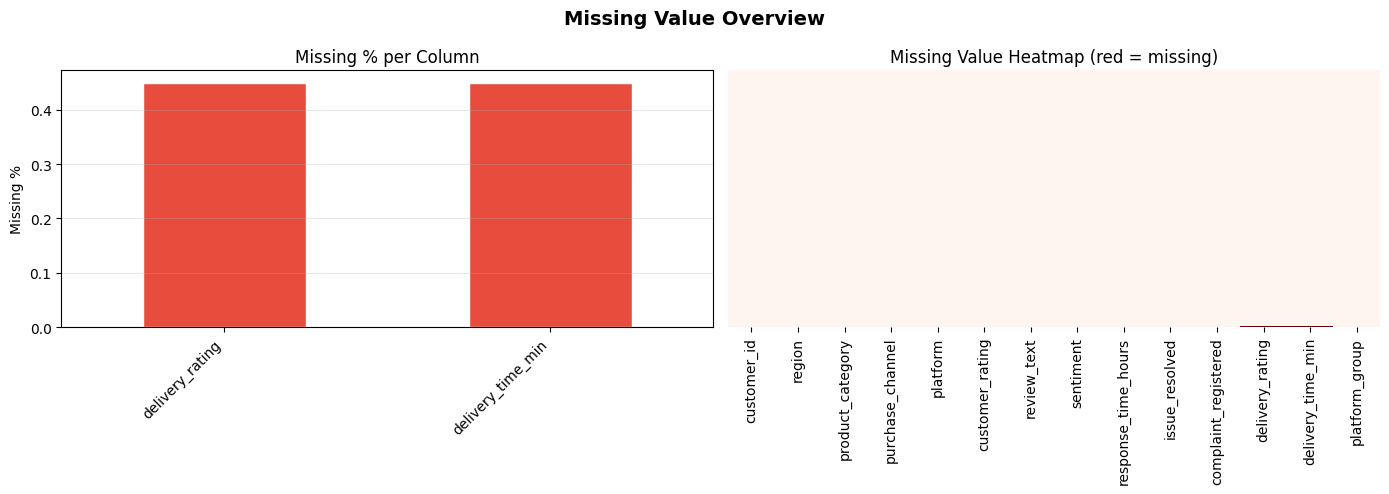

In [2]:
print("=" * 55)
print("MISSING VALUE ANALYSIS")
print("=" * 55)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Dtype': df.dtypes
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_df)
print(f"\nTotal missing cells : {df.isnull().sum().sum()}")
print(f"Total cells         : {df.size}")
print(f"Overall missing %   : {df.isnull().sum().sum() / df.size * 100:.2f}%")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Missing Value Overview", fontweight='bold', fontsize=14)

missing_df['Missing %'].plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='white')
axes[0].set_title("Missing % per Column")
axes[0].set_ylabel("Missing %")
axes[0].set_xticklabels(missing_df.index, rotation=45, ha='right')
axes[0].grid(alpha=0.3, axis='y')

sns.heatmap(df.isnull(), cbar=False, ax=axes[1],
            cmap='Reds', yticklabels=False)
axes[1].set_title("Missing Value Heatmap (red = missing)")

plt.tight_layout()
plt.show()

## Statistical Summary Before Imputation


In [5]:
print("=" * 55)
print("STATISTICAL SUMMARY — BEFORE IMPUTATION")
print("=" * 55)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical columns : {num_cols}")
print(f"Categorical columns: {cat_cols}")

print("\n--- Numerical Stats ---")
print(df[num_cols].describe().T.round(3))

print("\n--- Categorical Stats ---")
for col in cat_cols:
    print(f"\n{col}:")
    print(f"  Unique values : {df[col].nunique()}")
    print(f"  Missing       : {df[col].isnull().sum()}")
    print(f"  Top value     : {df[col].mode()[0] if not df[col].mode().empty else 'N/A'}")
    print(f"  Value counts  :\n{df[col].value_counts().head(5)}")

STATISTICAL SUMMARY — BEFORE IMPUTATION

Numerical columns : ['customer_id', 'customer_rating', 'response_time_hours', 'delivery_rating', 'delivery_time_min']
Categorical columns: ['region', 'product_category', 'purchase_channel', 'platform', 'review_text', 'sentiment', 'issue_resolved', 'complaint_registered', 'platform_group']

--- Numerical Stats ---
                         count      mean       std   min     25%     50%  \
customer_id          1048575.0  2822.295  1625.369   1.0  1378.0  2846.0   
customer_rating      1048575.0     3.040     1.386   1.0     2.0     3.0   
response_time_hours  1048575.0    35.267    20.228   1.0    18.0    34.0   
delivery_rating      1043850.0     3.006     1.138   1.0     2.1     3.0   
delivery_time_min    1043850.0    35.070    14.860  10.0    22.0    35.0   

                        75%     max  
customer_id          4276.0  5567.0  
customer_rating         4.0     5.0  
response_time_hours    53.0    71.0  
delivery_rating         4.0     5.0

## Fill Missing Values (Mean / Median / Mode)


In [6]:
print("=" * 55)
print("MISSING VALUE IMPUTATION")
print("=" * 55)

df_imputed = df.copy()

# ── Numerical → Mean & Median ─────────────────────────────────────────────────
print("\n--- Numerical Columns ---")
for col in num_cols:
    n_missing = df_imputed[col].isnull().sum()
    if n_missing > 0:
        mean_val   = df_imputed[col].mean()
        median_val = df_imputed[col].median()
        skewness   = df_imputed[col].skew()

        # Use median if skewed (|skew| > 0.5), else mean
        if abs(skewness) > 0.5:
            fill_val   = median_val
            method     = "Median"
        else:
            fill_val   = mean_val
            method     = "Mean"

        df_imputed[col].fillna(fill_val, inplace=True)
        print(f"  {col:<40} | Missing: {n_missing:>4} | Method: {method} | Fill value: {fill_val:.3f}  (skew={skewness:.2f})")
    else:
        print(f"  {col:<40} | No missing values")

# ── Categorical → Mode (Maximum Count) ───────────────────────────────────────
print("\n--- Categorical Columns ---")
for col in cat_cols:
    n_missing = df_imputed[col].isnull().sum()
    if n_missing > 0:
        mode_val = df_imputed[col].mode()[0]
        df_imputed[col].fillna(mode_val, inplace=True)
        print(f"  {col:<40} | Missing: {n_missing:>4} | Method: Mode | Fill value: '{mode_val}'")
    else:
        print(f"  {col:<40} | No missing values")

print(f"\n✅ Missing values after imputation: {df_imputed.isnull().sum().sum()}")

MISSING VALUE IMPUTATION

--- Numerical Columns ---
  customer_id                              | No missing values
  customer_rating                          | No missing values
  response_time_hours                      | No missing values
  delivery_rating                          | Missing: 4725 | Method: Mean | Fill value: 3.006  (skew=-0.01)
  delivery_time_min                        | Missing: 4725 | Method: Mean | Fill value: 35.070  (skew=0.01)

--- Categorical Columns ---
  region                                   | No missing values
  product_category                         | No missing values
  purchase_channel                         | No missing values
  platform                                 | No missing values
  review_text                              | No missing values
  sentiment                                | No missing values
  issue_resolved                           | No missing values
  complaint_registered                     | No missing values
  platform

## Before vs After Comparison


BEFORE vs AFTER IMPUTATION — COMPARISON


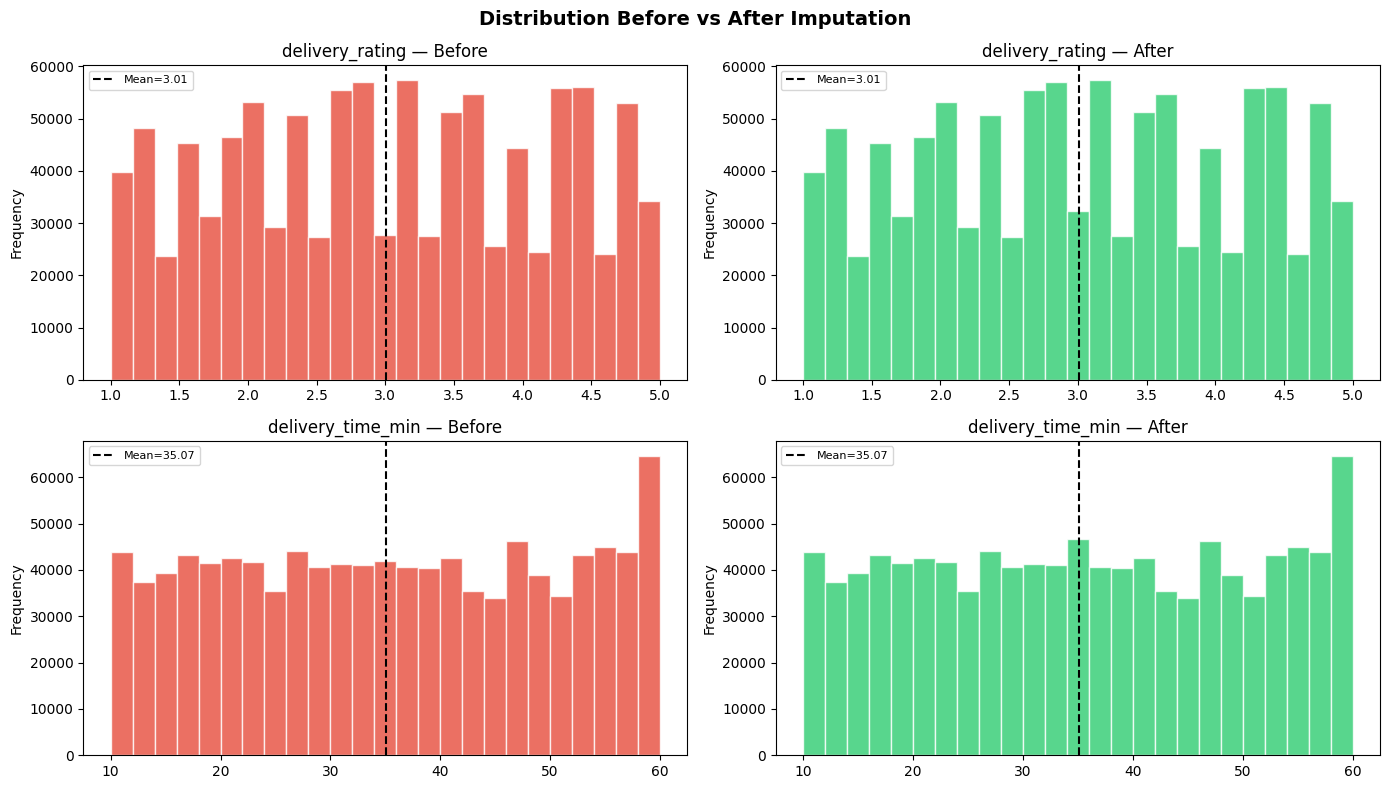


--- Numerical Stats AFTER Imputation ---
                         count      mean       std   min     25%     50%  \
customer_id          1048575.0  2822.295  1625.369   1.0  1378.0  2846.0   
customer_rating      1048575.0     3.040     1.386   1.0     2.0     3.0   
response_time_hours  1048575.0    35.267    20.228   1.0    18.0    34.0   
delivery_rating      1048575.0     3.006     1.135   1.0     2.1     3.0   
delivery_time_min    1048575.0    35.070    14.827  10.0    22.0    35.0   

                        75%     max  
customer_id          4276.0  5567.0  
customer_rating         4.0     5.0  
response_time_hours    53.0    71.0  
delivery_rating         4.0     5.0  
delivery_time_min      48.0    60.0  


In [7]:
print("=" * 55)
print("BEFORE vs AFTER IMPUTATION — COMPARISON")
print("=" * 55)

imputed_num_cols = [c for c in num_cols if df[c].isnull().sum() > 0]

if imputed_num_cols:
    fig, axes = plt.subplots(len(imputed_num_cols), 2,
                              figsize=(14, 4 * len(imputed_num_cols)))
    if len(imputed_num_cols) == 1:
        axes = np.array([axes])
    fig.suptitle("Distribution Before vs After Imputation", fontweight='bold', fontsize=14)

    for i, col in enumerate(imputed_num_cols):
        # Before
        axes[i, 0].hist(df[col].dropna(), bins=25, color='#e74c3c',
                         edgecolor='white', alpha=0.8)
        axes[i, 0].set_title(f"{col} — Before")
        axes[i, 0].set_ylabel("Frequency")
        axes[i, 0].axvline(df[col].mean(), color='black', linestyle='--',
                            linewidth=1.5, label=f"Mean={df[col].mean():.2f}")
        axes[i, 0].legend(fontsize=8)

        # After
        axes[i, 1].hist(df_imputed[col], bins=25, color='#2ecc71',
                         edgecolor='white', alpha=0.8)
        axes[i, 1].set_title(f"{col} — After")
        axes[i, 1].set_ylabel("Frequency")
        axes[i, 1].axvline(df_imputed[col].mean(), color='black', linestyle='--',
                            linewidth=1.5, label=f"Mean={df_imputed[col].mean():.2f}")
        axes[i, 1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns had missing values to compare.")

# Stats comparison table
print("\n--- Numerical Stats AFTER Imputation ---")
print(df_imputed[num_cols].describe().T.round(3))

## Preprocessing (Encoding + Feature Engineering)

PREPROCESSING — ENCODING & FEATURE ENGINEERING
  Encoded: region  →  ['central', 'east', 'north', 'south', 'west'] ...
  Encoded: product_category  →  ['automobile', 'beauty', 'books', 'electronics', 'fashion'] ...
  Encoded: purchase_channel  →  ['online'] ...
  Encoded: platform  →  ['ajio', 'amazon', 'bigbasket', 'boat', 'croma'] ...
  Encoded: review_text  →  ['amazing experience, highly recommend!', 'average experience overall.', 'customer service was unhelpful.', 'delivery was fine, product is decent.', 'excellent product! exceeded expectations.'] ...
  Encoded: sentiment  →  ['negative', 'neutral', 'positive'] ...
  Encoded: issue_resolved  →  ['no', 'yes'] ...
  Encoded: complaint_registered  →  ['no', 'yes'] ...
  Encoded: platform_group  →  ['ajio', 'amazon', 'bigbasket', 'boat', 'croma'] ...


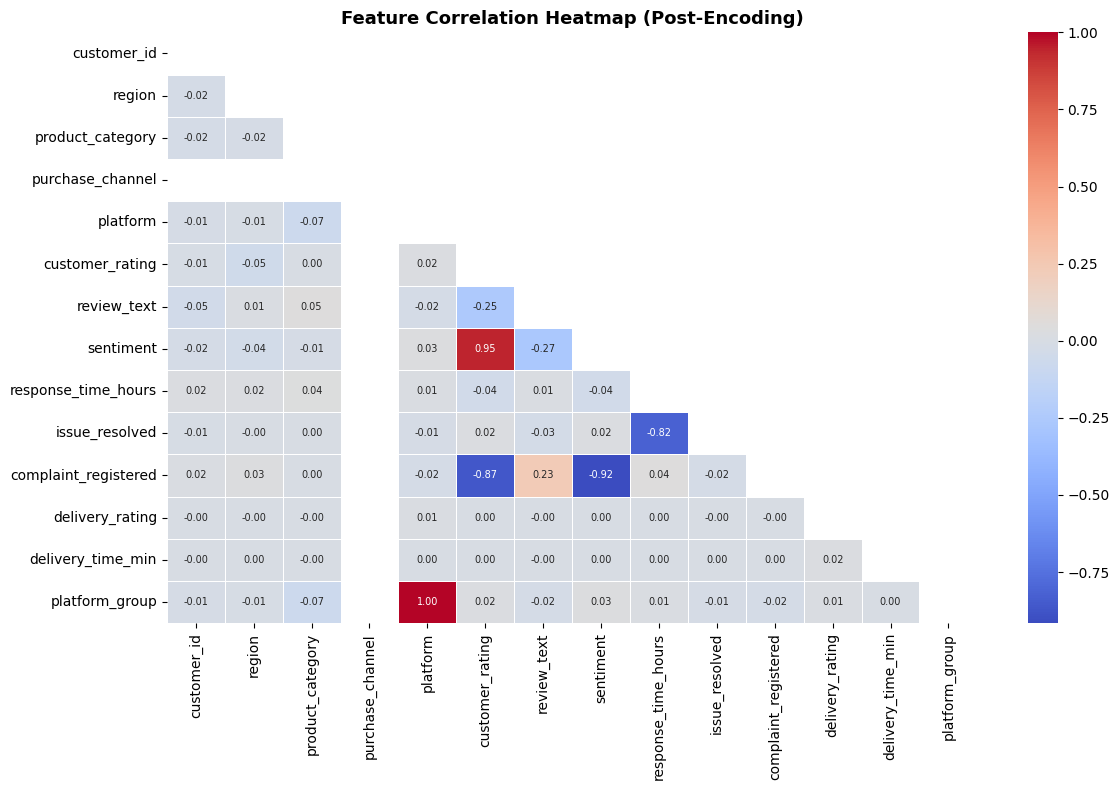


Final model-ready dataset shape: (1048575, 14)
   customer_id  region  product_category  purchase_channel  platform  \
0          513       1                 8                 0         7   
1          513       1                 8                 0         7   
2          513       1                 8                 0         7   
3          513       1                 8                 0         7   
4          513       1                 8                 0         7   

   customer_rating  review_text  sentiment  response_time_hours  \
0                2           12          0                   69   
1                2           12          0                   69   
2                2           12          0                   69   
3                2           12          0                   69   
4                2           12          0                   69   

   issue_resolved  complaint_registered  delivery_rating  delivery_time_min  \
0               0                    

In [8]:
print("=" * 55)
print("PREPROCESSING — ENCODING & FEATURE ENGINEERING")
print("=" * 55)

df_model = df_imputed.copy()

# ── Label Encode all categorical columns ──────────────────────────────────────
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le
    print(f"  Encoded: {col}  →  {list(le.classes_[:5])} ...")

# ── Correlation heatmap after encoding ───────────────────────────────────────
plt.figure(figsize=(12, 8))
corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title("Feature Correlation Heatmap (Post-Encoding)", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nFinal model-ready dataset shape: {df_model.shape}")
print(df_model.head())

Prediction Model 1: Classification (Sentiment)


## Prediction Model 1: Classification (Sentiment)


PREDICTION MODEL 1 — SENTIMENT CLASSIFICATION
Train size: (838860, 11), Test size: (209715, 11)

Logistic Regression Accuracy : 1.0000 (100.00%)
Random Forest Accuracy       : 1.0000 (100.00%)

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     82656
     neutral       1.00      1.00      1.00     40001
    positive       1.00      1.00      1.00     87058

    accuracy                           1.00    209715
   macro avg       1.00      1.00      1.00    209715
weighted avg       1.00      1.00      1.00    209715



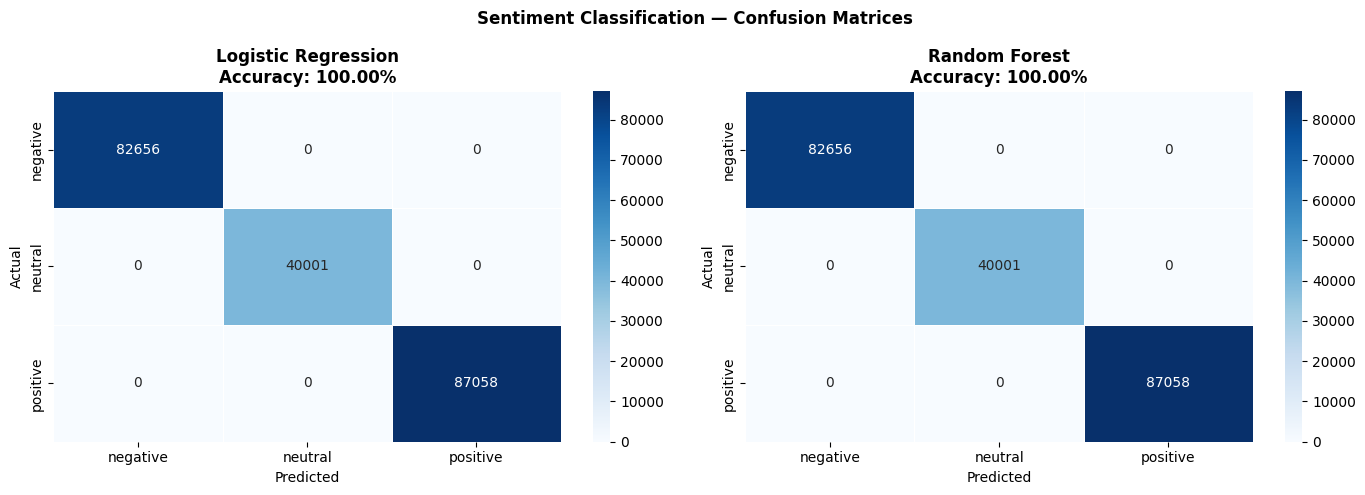

In [10]:
print("=" * 55)
print("PREDICTION MODEL 1 — SENTIMENT CLASSIFICATION")
print("=" * 55)

# Target: sentiment (positive / neutral / negative)
target_col = 'sentiment'
feature_cols = [c for c in df_model.columns
                if c not in [target_col, 'customer_id', 'review_text']]

X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

# ── Logistic Regression ───────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f"\nLogistic Regression Accuracy : {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"Random Forest Accuracy       : {acc_rf:.4f} ({acc_rf*100:.2f}%)")

# Classification Report
print("\n--- Random Forest Classification Report ---")
sentiment_labels = le_dict['sentiment'].classes_
print(classification_report(y_test, y_pred_rf, target_names=sentiment_labels))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sentiment Classification — Confusion Matrices", fontweight='bold')

for ax, y_pred, title in zip(axes, [y_pred_lr, y_pred_rf],
                               ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=sentiment_labels, yticklabels=sentiment_labels,
                linewidths=0.5)
    ax.set_title(f"{title}\nAccuracy: {accuracy_score(y_test, y_pred)*100:.2f}%",
                 fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Prediction Model 2: Regression (Response Time)


PREDICTION MODEL 2 — RESPONSE TIME REGRESSION

Linear Regression Results:
  MSE  : 133.7946
  RMSE : 11.5670
  R²   : 0.6731

Top 5 Influential Features:
                Feature  Coefficient
6        issue_resolved   -35.568834
7  complaint_registered     0.578065
0                region     0.327962
1      product_category     0.324794
4       customer_rating    -0.121809


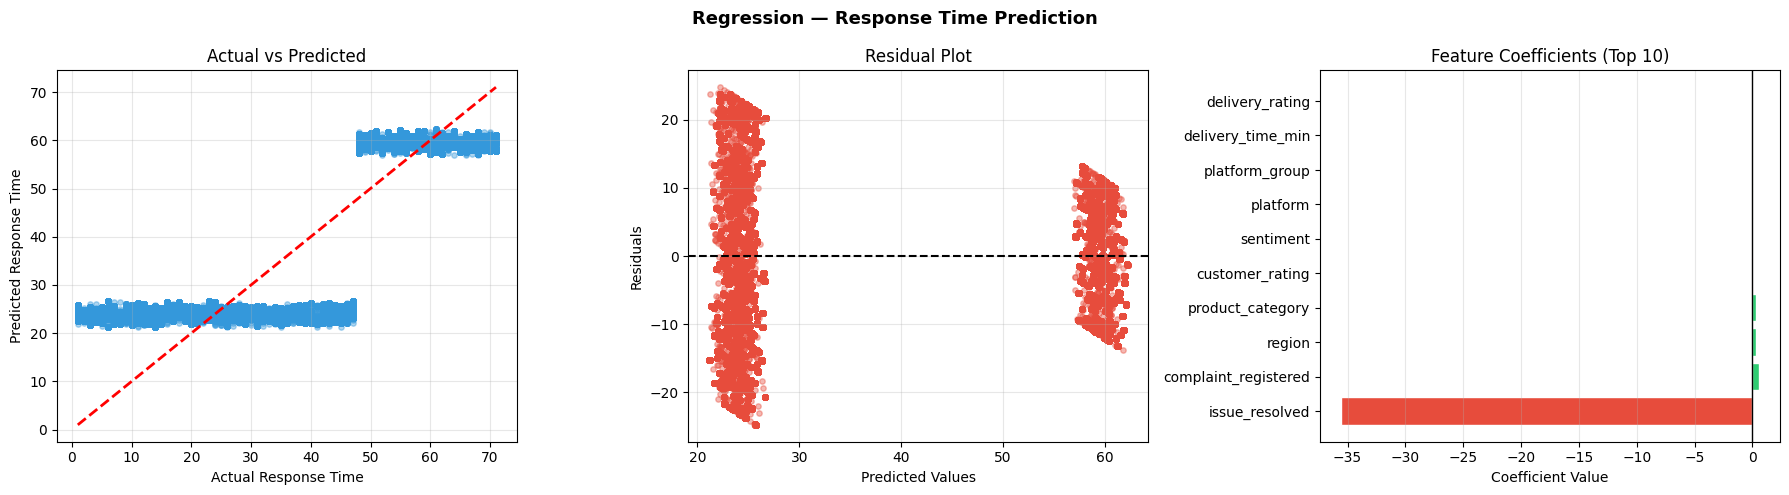

In [11]:
print("=" * 55)
print("PREDICTION MODEL 2 — RESPONSE TIME REGRESSION")
print("=" * 55)

target_reg = 'response_time_hours'
feature_reg = [c for c in df_model.columns
               if c not in [target_reg, 'customer_id', 'review_text']]

X_r = df_model[feature_reg]
y_r = df_model[target_reg]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42)

# ── Linear Regression ─────────────────────────────────────────────────────────
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)
y_pred_reg = lin_reg.predict(X_test_r)

mse  = mean_squared_error(y_test_r, y_pred_reg)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_r, y_pred_reg)

print(f"\nLinear Regression Results:")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

# Feature Importance (coefficients)
coef_df = pd.DataFrame({
    'Feature': feature_reg,
    'Coefficient': lin_reg.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(f"\nTop 5 Influential Features:\n{coef_df.head()}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Regression — Response Time Prediction", fontweight='bold', fontsize=13)

# Actual vs Predicted
axes[0].scatter(y_test_r, y_pred_reg, alpha=0.4, color='#3498db', s=15)
axes[0].plot([y_test_r.min(), y_test_r.max()],
             [y_test_r.min(), y_test_r.max()], 'r--', linewidth=2)
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual Response Time")
axes[0].set_ylabel("Predicted Response Time")
axes[0].grid(alpha=0.3)

# Residuals
residuals = y_test_r - y_pred_reg
axes[1].scatter(y_pred_reg, residuals, alpha=0.4, color='#e74c3c', s=15)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title("Residual Plot")
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals")
axes[1].grid(alpha=0.3)

# Feature Importance
top10 = coef_df.head(10)
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top10['Coefficient']]
axes[2].barh(top10['Feature'], top10['Coefficient'], color=colors, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_title("Feature Coefficients (Top 10)")
axes[2].set_xlabel("Coefficient Value")
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Feature Importance (Random Forest)


FEATURE IMPORTANCE — RANDOM FOREST
                 Feature  Importance
4        customer_rating    0.587012
7   complaint_registered    0.380280
5    response_time_hours    0.014149
1       product_category    0.008659
0                 region    0.005309
3               platform    0.001800
10        platform_group    0.001756
6         issue_resolved    0.000995
9      delivery_time_min    0.000020
8        delivery_rating    0.000018
2       purchase_channel    0.000000


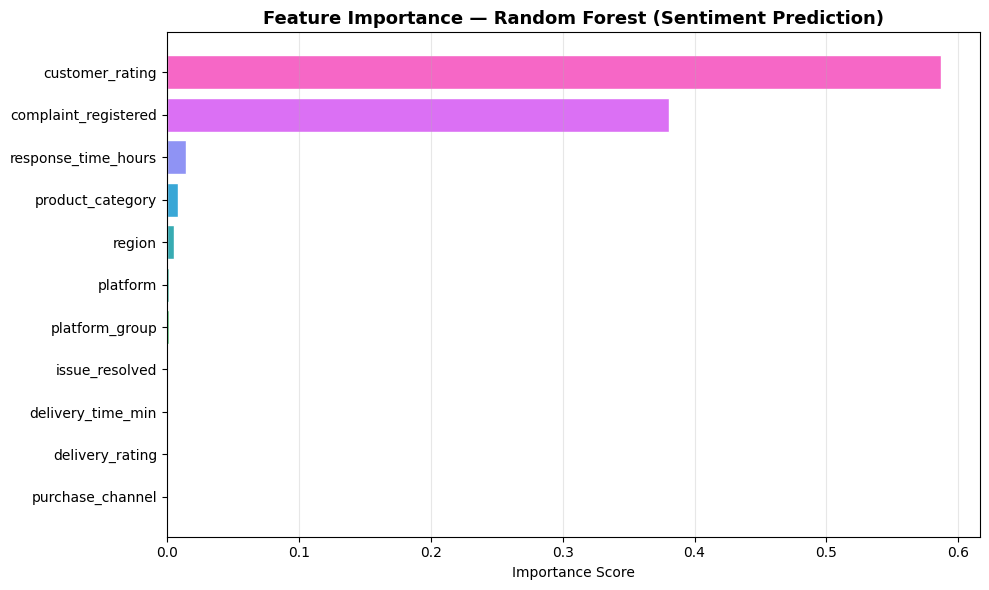

In [12]:
print("=" * 55)
print("FEATURE IMPORTANCE — RANDOM FOREST")
print("=" * 55)

feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(feat_imp)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("husl", len(feat_imp))
plt.barh(feat_imp['Feature'][::-1], feat_imp['Importance'][::-1],
         color=colors, edgecolor='white')
plt.title("Feature Importance — Random Forest (Sentiment Prediction)",
          fontweight='bold', fontsize=13)
plt.xlabel("Importance Score")
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Final Summary


In [13]:
print("=" * 65)
print("  ASSIGNMENT 2 — SUMMARY REPORT")
print("=" * 65)

print(f"""
📦 Dataset        : E-Commerce Customer Feedback
   Rows           : {df.shape[0]}  |  Columns: {df.shape[1]}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 MISSING VALUE IMPUTATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ Numerical columns  → Mean (low skew) / Median (high skew)
  ✔ Categorical columns → Mode (Maximum Count)
  ✔ Missing after imputation: {df_imputed.isnull().sum().sum()}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PREPROCESSING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ Label Encoding on all categorical columns
  ✔ Correlation heatmap plotted

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PREDICTION MODELS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model 1 — Sentiment Classification
    • Logistic Regression  → Accuracy: {acc_lr*100:.2f}%
    • Random Forest        → Accuracy: {acc_rf*100:.2f}%

  Model 2 — Response Time Regression
    • Linear Regression    → R²: {r2:.4f}, RMSE: {rmse:.4f}
""")

  ASSIGNMENT 2 — SUMMARY REPORT

📦 Dataset        : E-Commerce Customer Feedback
   Rows           : 1048575  |  Columns: 14

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 MISSING VALUE IMPUTATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ Numerical columns  → Mean (low skew) / Median (high skew)
  ✔ Categorical columns → Mode (Maximum Count)
  ✔ Missing after imputation: 0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PREPROCESSING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ Label Encoding on all categorical columns
  ✔ Correlation heatmap plotted

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PREDICTION MODELS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model 1 — Sentiment Classification
    • Logistic Regression  → Accuracy: 100.00%
    • Random Forest        → Accuracy: 100.00%

  Model 2 — Response Time Regression
    • Linear Regression    → R²: 0.6731,